In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")

In [2]:
nav_df = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

perf_df = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

portfolio_df = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

benchmark_df = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

In [3]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

In [4]:
sample_fund = nav_df[
    nav_df["amfi_code"] == 119551
].sort_values("date")

begin_nav = sample_fund.iloc[0]["nav"]
end_nav = sample_fund.iloc[-1]["nav"]

years = (
    sample_fund.iloc[-1]["date"] -
    sample_fund.iloc[0]["date"]
).days / 365

cagr = ((end_nav / begin_nav) ** (1 / years)) - 1

print("CAGR:", round(cagr * 100, 2), "%")

CAGR: 25.78 %


In [5]:
sample_fund["daily_return"] = (
    sample_fund["nav"].pct_change()
)

sample_fund.head()

,amfi_code,date,nav,daily_return
21850,119551,2022-01-03,54.3856,NaN
21851,119551,2022-01-04,54.3474,-0.000702
21852,119551,2022-01-05,54.6869,0.006247
21853,119551,2022-01-06,55.4550,0.014045
21854,119551,2022-01-07,55.3692,-0.001547


In [7]:
volatility = (
    sample_fund["daily_return"].std()
) * np.sqrt(252)

print(
    "Annualized Volatility:",
    round(volatility * 100, 2),
    "%"
)

Annualized Volatility: 13.74 %


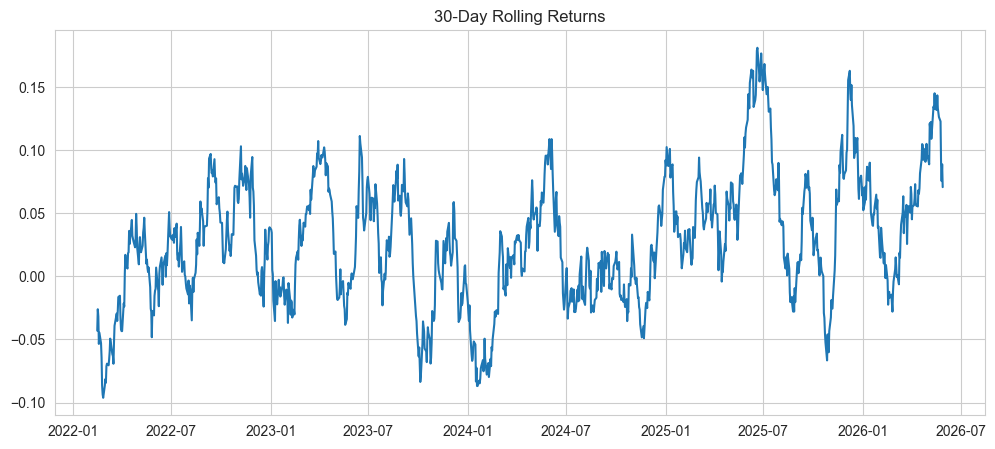

In [8]:
sample_fund["rolling_30d"] = (
    sample_fund["nav"]
    .pct_change(30)
)

plt.plot(
    sample_fund["date"],
    sample_fund["rolling_30d"]
)

plt.title("30-Day Rolling Returns")

plt.show()

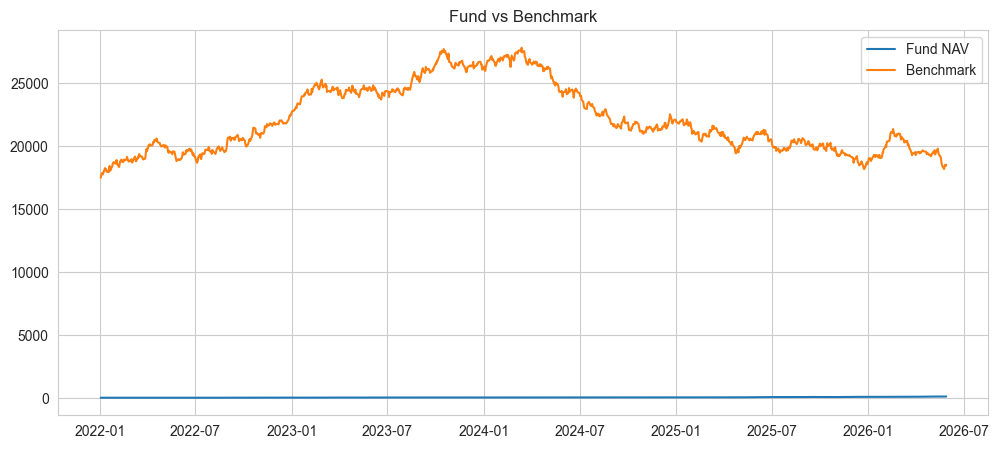

In [9]:
benchmark_sample = benchmark_df[
    benchmark_df["index_name"] ==
    benchmark_df["index_name"].iloc[0]
]

plt.plot(
    sample_fund["date"],
    sample_fund["nav"],
    label="Fund NAV"
)

plt.plot(
    benchmark_sample["date"],
    benchmark_sample["close_value"],
    label="Benchmark"
)

plt.legend()

plt.title("Fund vs Benchmark")

plt.show()

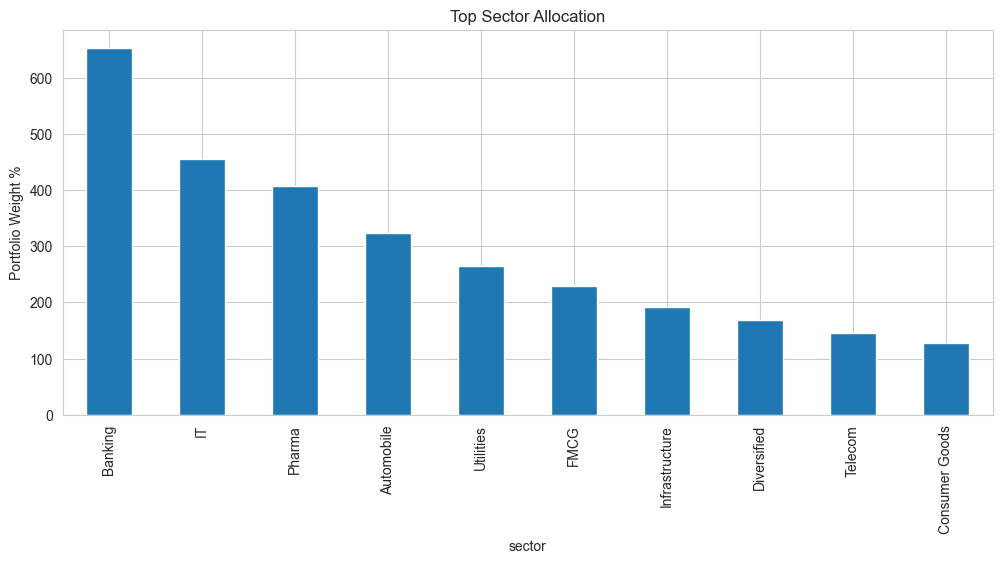

In [10]:
sector_alloc = (
    portfolio_df.groupby("sector")
    ["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_alloc.head(10).plot(kind="bar")

plt.title("Top Sector Allocation")

plt.ylabel("Portfolio Weight %")

plt.show()

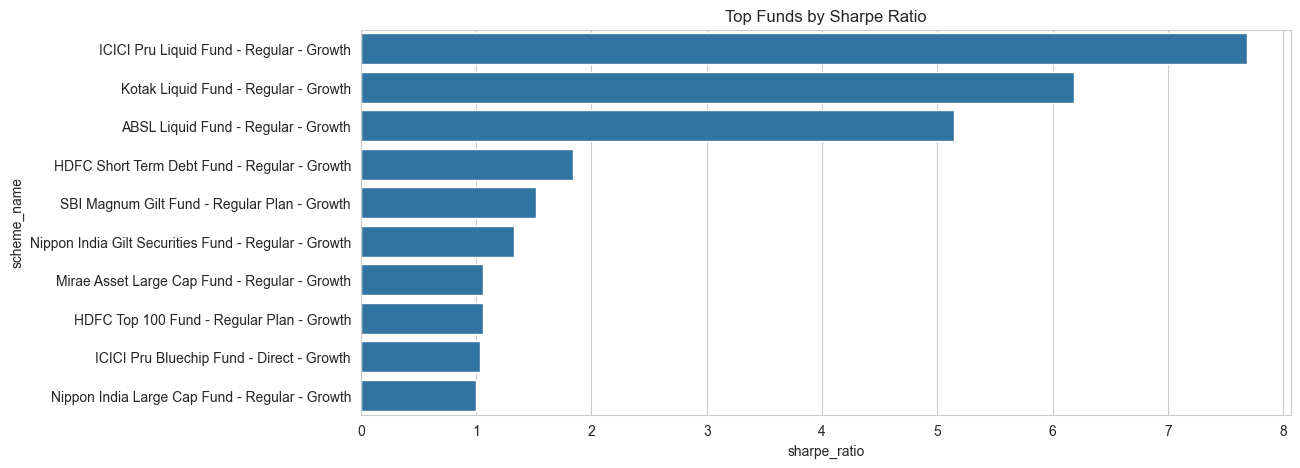

In [11]:
top_sharpe = perf_df.sort_values(
    by="sharpe_ratio",
    ascending=False
)

sns.barplot(
    data=top_sharpe.head(10),
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top Funds by Sharpe Ratio")

plt.show()

In [12]:
kpis = {
    "Average 1Y Return":
        perf_df["return_1yr_pct"].mean(),

    "Average Sharpe Ratio":
        perf_df["sharpe_ratio"].mean(),

    "Highest AUM":
        perf_df["aum_crore"].max(),

    "Average Expense Ratio":
        perf_df["expense_ratio_pct"].mean()
}

kpis

{'Average 1Y Return': np.float64(14.376),
 'Average Sharpe Ratio': np.float64(1.3617500000000002),
 'Highest AUM': np.int64(49046),
 'Average Expense Ratio': np.float64(1.237)}